 # Phoneme‑Level EDA for L2‑ARCTIC



 This notebook performs an in‑depth analysis of IPA phoneme distributions in the L2‑ARCTIC dataset.


 It uses the helper module `utils.load_l2arctic` to load preprocessed `scripted` and `spontaneous` splits as pandas DataFrames with cleaned IPA.



 We will:

 - Load the scripted and spontaneous splits as ready‑to‑use DataFrames

 - Extract phoneme inventories from the IPA strings

 - Compute overall and per‑speaker / per‑L1 phoneme frequency distributions

 - Visualise distributions and phoneme–L1 heatmaps

 - Use PanPhon to map phonemes to articulatory feature families.

 ## Setup



 Install and import required libraries. Run the cell below once in a fresh environment.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import panphon

from src.utils.load_l2arctic import load_scripted, load_spontaneous

sns.set(style="whitegrid")


 ## Load preprocessed data



 Use the helper functions to obtain preprocessed DataFrames with stress‑free

 IPA transcriptions.

In [4]:
df = load_scripted()
# df = load_spontaneous()

df.head()

,ipa,text,g2p,speaker_code,speaker_gender,speaker_native_language,duration_s,ipa_wstress,text_num_chars,text_num_words,ipa_num_chars
0,fɔɹðʌtwɛntiɪθtaɪmðætivnɪŋkðʌtumɛnʃʊkhænss,for the twentieth time that evening the two me...,fɔɹðʌtwɛntiʌθtaɪmðætivnɪŋðʌtumɛnʃʊkhændz,ABA,m,Arabic,4.920,fɔˈɹðʌˈtwɛˈntiɪθtaɪˈmðæˈtiˈvnɪŋkðʌˈtuˈmɛˈnʃʊˈk...,59,11,41
1,wɪlwiɛvʌfɔɹɡɛtɛt,will we ever forget it,wɪlwiɛvɝfɝɡɛtɪt,ABA,m,Arabic,2.390,wɪˈlwiˈɛˈvʌfɔɹɡɛˈtɛt,22,5,16
2,ɡɑdblɛsðʌmaɪhoʊpaɪlɡoʊɔnsiɪŋðɛmfɝɛvʌ,god bless em i hope i'll go on seeing them for...,ɡɑdblɛsɛmaɪhoʊpaɪlɡoʊɑnsiɪŋðɛmfɝɛvɝ,ABA,m,Arabic,4.749,ɡɑˈdblɛˈsðʌmaɪˈhoʊˈpaɪˈlɡoʊˈɔˈnsiˈɪŋðɛˈmfɝɛˈvʌ,50,11,36
3,ændjuɔlwizwɔnttusiɛtɛnðʌsʊbɝlʌtɪvdɪɡɹi,and you always want to see it in the superlati...,ʌndjuɔlweɪzwɑnttusiɪtɪnðʌsʊpɝlʌtɪvdɪɡɹi,ABA,m,Arabic,4.980,æˈndjuˈɔˈlwizwɔˈnttuˈsiˈɛtɛnðʌsʊbɝˈlʌtɪvdɪɡɹiˈ,55,11,38
4,ɡædjʊɹlɛtɹkeɪmdʒʌstɪntaɪm,gad your letter came just in time,ɡædjɔɹlɛtɝkeɪmdʒʌstɪntaɪm,ABA,m,Arabic,3.160,ɡæˈdjʊˈɹlɛˈtɹkeɪˈmdʒʌˈstɪntaɪˈm,33,7,25


 ## Tokenisation of IPA into phoneme symbols



 For this analysis we treat each IPA symbol as a phoneme token. If your

 pipeline uses multi‑character symbols (e.g. affricates like `t͡ʃ`), you can

 later extend the tokenizer to handle them explicitly.

In [5]:
def ipa_to_chars(s: str):
    """Simple tokenizer: split IPA string into a list of characters."""
    return list(s) if isinstance(s, str) else []


def flatten_ipa_column(series: pd.Series):
    """Flatten a Series of IPA strings into a list of tokens (characters)."""
    return [ch for s in series.dropna() for ch in ipa_to_chars(s)]


all_phones = flatten_ipa_column(df["ipa"])

len(all_phones)

124903

 ## Overall phoneme distributions



 Compute overall phoneme frequency distributions for the scripted and

 spontaneous splits and visualise the most common symbols.

In [6]:
def phone_freq(tokens):
    c = Counter(tokens)
    df = (
        pd.DataFrame.from_dict(c, orient="index", columns=["count"])
        .sort_values("count", ascending=False)
    )
    df["rel_freq"] = df["count"] / df["count"].sum()
    return df


phone_freq = phone_freq(all_phones)

phone_freq.head(20)


,count,rel_freq
ɪ,11304,0.090502
ʌ,10670,0.085426
t,7755,0.062088
n,7140,0.057164
d,6892,0.055179
s,6556,0.052489
i,5781,0.046284
ɹ,4589,0.036741
l,4259,0.034098
ɛ,3549,0.028414


/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 618 (\N{LATIN LETTER SMALL CAPITAL I}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 652 (\N{LATIN SMALL LETTER TURNED V}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 633 (\N{LATIN SMALL LETTER TURNED R}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 603 (\N{LATIN SMALL LETTER OPEN E}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 650 (\N{LATIN SMALL LETTER UPSILON}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 596 (\N{LATIN SMALL LETTER OPEN O}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2052778/1313025505.py:10: UserWarning: Glyph 605 (\N{LATIN SMALL LETTER REVERSED OPEN E WITH HOOK}) missing

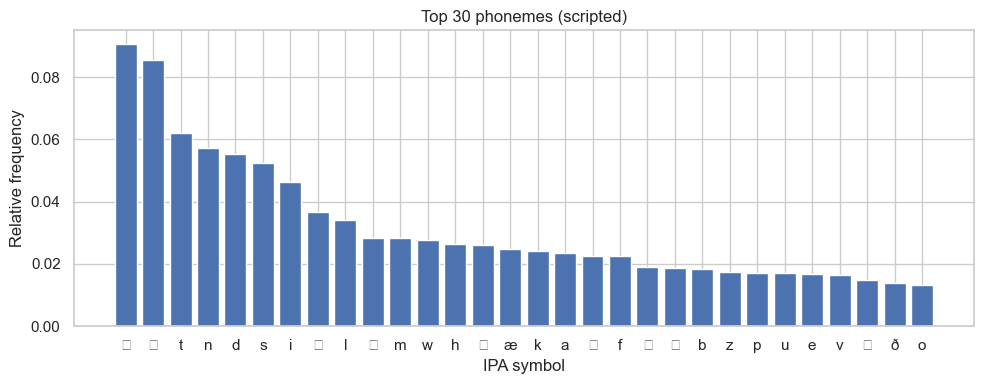

In [9]:
# Plot top N phonemes for scripted and spontaneous
TOP_N = 30

plt.figure(figsize=(10, 4))
subset = phone_freq.head(TOP_N)
plt.bar(subset.index, subset["rel_freq"], color="C0")
plt.title(f"Top {TOP_N} phonemes (scripted)")
plt.xlabel("IPA symbol")
plt.ylabel("Relative frequency")
plt.tight_layout()
plt.show()


 ## Phoneme distributions by native language (L1)



 Compute phoneme distributions for each native language group and

 visualise them as a heatmap.

/vol/bitbucket/tsv22/accent-robust-asr/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 633 (\N{LATIN SMALL LETTER TURNED R}) missing from font(s) Arial.
  fig.canvas.draw()
/vol/bitbucket/tsv22/accent-robust-asr/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 652 (\N{LATIN SMALL LETTER TURNED V}) missing from font(s) Arial.
  fig.canvas.draw()
/vol/bitbucket/tsv22/accent-robust-asr/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 618 (\N{LATIN LETTER SMALL CAPITAL I}) missing from font(s) Arial.
  fig.canvas.draw()
/vol/bitbucket/tsv22/accent-robust-asr/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 650 (\N{LATIN SMALL LETTER UPSILON}) missing from font(s) Arial.
  fig.canvas.draw()
/vol/bitbucket/tsv22/accent-robust-asr/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 609 (\N{LATIN SMALL LETTER SCRIPT G}) missing from font(s) Arial.
  fig.canvas.draw()


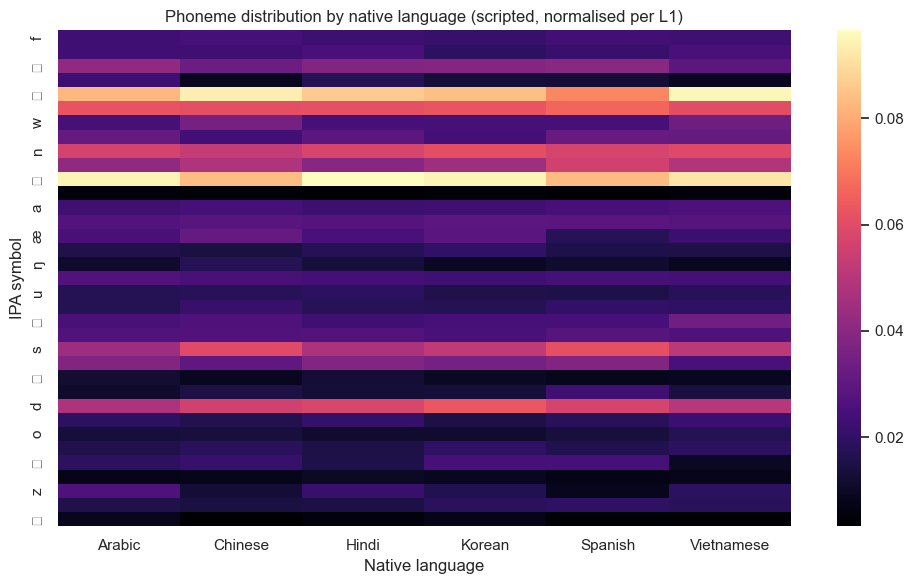

In [10]:
def phone_counts_by_group(df: pd.DataFrame, group_col: str):
    group_counts = {}
    for group, sub in df.groupby(group_col):
        tokens = flatten_ipa_column(sub["ipa"])
        group_counts[group] = Counter(tokens)
    return group_counts


l1_counts = phone_counts_by_group(df, "speaker_native_language")

# Convert to DataFrame: rows = phones, columns = L1s
l1_df = pd.DataFrame(l1_counts).fillna(0).astype(int)

# Filter to reasonably frequent phones
min_total = 500
phone_totals = l1_df.sum(axis=1)
common_phones = phone_totals[phone_totals >= min_total].index
l1_df_common = l1_df.loc[common_phones]

# Column-normalise (proportions per L1)
l1_df_prop = l1_df_common.div(l1_df_common.sum(axis=0), axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(l1_df_prop, cmap="magma", annot=False)
plt.title("Phoneme distribution by native language (scripted, normalised per L1)")
plt.xlabel("Native language")
plt.ylabel("IPA symbol")
plt.tight_layout()
plt.show()


 ## Phoneme distributions by speaker



 Inspect per‑speaker phoneme frequency distributions for the scripted split.

In [11]:
def phone_counts_by_speaker(df: pd.DataFrame):
    speaker_counts = {}
    for spk, sub in df.groupby("speaker_code"):
        tokens = flatten_ipa_column(sub["ipa"])
        speaker_counts[spk] = Counter(tokens)
    return speaker_counts


speaker_counts = phone_counts_by_speaker(df)

# Example: show top phonemes for one speaker
example_spk = list(speaker_counts.keys())[0]
print("Example speaker:", example_spk)
print(
    pd.Series(speaker_counts[example_spk])
    .sort_values(ascending=False)
    .head(20)
)


Example speaker: ABA
ɪ    496
ʌ    462
t    327
n    301
d    249
s    218
ɹ    204
i    203
l    186
ɛ    167
k    161
ʊ    159
z    155
m    144
h    140
ð    132
w    130
a    122
æ    119
f    115
dtype: int64


 ## Mapping phonemes to articulatory feature families (PanPhon)



 Use PanPhon to map IPA segments to a rich set of articulatory features

 (e.g. vowel vs consonant, place, manner, voicing) and aggregate frequencies

 over these feature dimensions.[web:76][web:79][web:101]

In [19]:
ft = panphon.FeatureTable()

def seg_features(seg: str):
    """
    Return a dict of PanPhon features for a given segment (single IPA symbol).
    """
    if not isinstance(seg, str) or not seg:
        return None

    try:
        vec_list = ft.word_to_vector_list(seg, numeric=True)
    except Exception:
        # PanPhon raises its own errors for unknown symbols
        return None

    if not vec_list:
        return None

    vec = vec_list[0]
    return dict(zip(ft.names, vec))


# Build a feature DataFrame indexed by segment (scripted inventory)
feat_rows = []
for seg in phone_freq.index:
    feats = seg_features(seg)
    if feats is not None:
        feats["seg"] = seg
        feat_rows.append(feats)

feat_df = pd.DataFrame(feat_rows).set_index("seg")

print("Feature cols:", feat_df.columns.tolist())
feat_df.head()


Feature cols: ['syl', 'son', 'cons', 'cont', 'delrel', 'lat', 'nas', 'strid', 'voi', 'sg', 'cg', 'ant', 'cor', 'distr', 'lab', 'hi', 'lo', 'back', 'round', 'velaric', 'tense', 'long', 'hitone', 'hireg']


,syl,son,cons,cont,delrel,lat,nas,strid,voi,sg,...,lab,hi,lo,back,round,velaric,tense,long,hitone,hireg
seg,,,,,,,,,,,,,,,,,,,,,
ɪ,1,1,-1,1,-1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,0,0
ʌ,1,1,-1,1,-1,-1,-1,-1,1,-1,...,-1,-1,-1,1,-1,-1,1,-1,0,0
t,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,0,-1,0,0
n,-1,1,1,-1,-1,-1,1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,0,-1,0,0
d,-1,-1,1,-1,-1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,0,-1,0,0


 ### Vowels vs consonants



 Use the PanPhon feature `syllabic` (1 ~ vowel‑like, 0 ~ consonant‑like)

 for a coarse‑grained distinction between vowels and consonants.

In [17]:
# Merge frequency and feature information
pf = phone_freq.join(feat_df, how="left")

vowel_mask = pf["syl"] == 1
cons_mask = pf["syl"] != 1

vowel_tokens = pf.loc[vowel_mask, "count"].sum()
cons_tokens = pf.loc[cons_mask, "count"].sum()

total_tokens = pf["count"].sum()

print("Vowel proportion:", vowel_tokens / total_tokens)
print("Consonant proportion:", cons_tokens / total_tokens)


Vowel proportion: 0.41223189194815174
Consonant proportion: 0.5877681080518482


 ### Example: place of articulation distribution (consonants)



 Aggregate counts over consonants by broad place of articulation using

 selected PanPhon features (e.g. labial, coronal, dorsal).

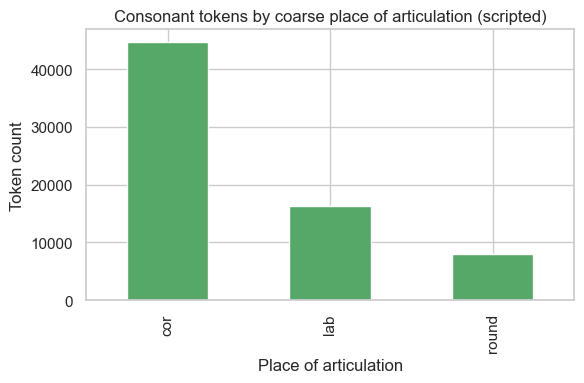

lab      16309.0
cor      44659.0
round     8054.0
dtype: float64

In [20]:
# Define a simple mapping from feature flags to coarse places
place_cols = ["lab", "cor", "round"]

place_counts = {place: 0 for place in place_cols}

for seg, row in pf.loc[cons_mask].iterrows():
    for place in place_cols:
        if place in row and row[place] == 1:
            place_counts[place] += row["count"]

place_series = pd.Series(place_counts)

plt.figure(figsize=(6, 4))
place_series.sort_values(ascending=False).plot(kind="bar", color="C2")
plt.title("Consonant tokens by coarse place of articulation (scripted)")
plt.xlabel("Place of articulation")
plt.ylabel("Token count")
plt.tight_layout()
plt.show()

place_series